# **Project Title : "Malaria Surveillance and Predictive Analytics Using Simulated Healthcare Data"**

#### Core Goal: "To clean, analyze, and model malaria-related healthcare data to identify patterns and predict malaria outcomes."

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df1 = pd.read_csv(r"C:\Users\FRINICT\Documents\Anavami and John Class\Malaria Dataset  Analysis\Malaria Simulation Data\malaria_patient_data.csv")

In [8]:
df1

,patient_id,age,state,season,mosquito_net,owns_tv,random_text
0,1000,9,G0mbe,NaN,N,Yes,123
1,1001,25,Ogun,Dry,YES,Yes,NaN
2,1002,68,Anambra,rainy,NaN,No,abc
3,1003,NaN,Abuja,NaN,N,NaN,123
4,1004,49,Plateau,R@iny,YES,Yes,abc
...,...,...,...,...,...,...,...
4495,5495,40,Imo,Rainy,No,No,abc
4496,5496,68,Delta,Rainy,YES,NaN,123
4497,5497,51,Ekiti,R@iny,no,No,NaN
4498,5498,54,Kaduna,dry,no,No,abc


In [9]:
# Dataset information
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_id    4500 non-null   int64 
 1   age           4453 non-null   object
 2   state         4500 non-null   object
 3   season        3728 non-null   object
 4   mosquito_net  3850 non-null   object
 5   owns_tv       3063 non-null   object
 6   random_text   3358 non-null   object
dtypes: int64(1), object(6)
memory usage: 246.2+ KB


In [10]:
# Sum of null rows
df1.isnull().sum()

patient_id         0
age               47
state              0
season           772
mosquito_net     650
owns_tv         1437
random_text     1142
dtype: int64

In [11]:
# Dataset columns
df1.columns

Index(['patient_id', 'age', 'state', 'season', 'mosquito_net', 'owns_tv',
       'random_text'],
      dtype='object')

In [12]:
df1.columns.tolist()

['patient_id',
 'age',
 'state',
 'season',
 'mosquito_net',
 'owns_tv',
 'random_text']

In [13]:
# Datatypes of each column
df1.dtypes

patient_id       int64
age             object
state           object
season          object
mosquito_net    object
owns_tv         object
random_text     object
dtype: object

In [14]:
df1["age"].unique()

array(['9', '25', '68', nan, '49', '11', '53', '54', '67', '15', '35',
       '16', '61', '59', '17', '10', '3', '28', '5', '32', '2', '14',
       '60', '8', '50', '48', '66', '62', '56', '72', '-5', '20', '64',
       '57', '31', '40', '39', '45', '19', '65', '75', '18', '73', '69',
       '51', '79', '1', '58', '77', '4', '71', '44', '37', '6', '43',
       '34', '23', '63', '36', '24', '22', '26', '55', '7', '38', '52',
       '46', '13', '21', '74', '78', '41', '29', '??', '12', '30', '27',
       '33', '42', '47', '70', '76'], dtype=object)

In [15]:
df1["state"].unique()

array(['G0mbe', 'Ogun', 'Anambra', 'Abuja', 'Plateau', 'Niger', 'Ondo',
       'Oyo', 'gombe', 'Zamfara', 'Delta', 'Kaduna', 'Nasarawa', 'Enugu',
       'Cross River', 'Borno', 'kogi', 'lagos ', 'Adamawa', 'crossriver',
       'Kwara', 'Benue', 'Ed0o', 'Rivers', 'Abla', 'Bauchi', 'S0koto',
       'Ekiti', 'Imo', 'benue', 'Kano', 'Lagos', 'Kaduba', 'katsina',
       'Bayelsa', 'Taraba', 'Jigawa', 'KAN0', 'Ebonyi', 'Yobe', 'Kebbis',
       '??Rivers', 'Osun'], dtype=object)

In [16]:
df1["state"].nunique()

43

In [17]:
df1["season"].unique()

array([nan, 'Dry', 'rainy', 'R@iny', 'Rainy', 'dry'], dtype=object)

In [18]:
df1["mosquito_net"].unique()

array(['N', 'YES', nan, 'Y', 'no', 'No', 'Yes'], dtype=object)

In [19]:
df1["owns_tv"].unique()

array(['Yes', 'No', nan], dtype=object)

In [20]:
df1["random_text"].unique()

array(['123', nan, 'abc', '@@@'], dtype=object)

In [21]:
df1["season"].value_counts()

season
rainy    760
R@iny    759
Rainy    759
Dry      727
dry      723
Name: count, dtype: int64

In [22]:
df1["mosquito_net"].value_counts()

mosquito_net
N      665
Yes    655
no     653
Y      651
YES    617
No     609
Name: count, dtype: int64

In [23]:
df1["owns_tv"].value_counts()

owns_tv
Yes    1597
No     1466
Name: count, dtype: int64

-------------------------------------------------------------------------------------------------

In [25]:
# another way to approach it
for col in df1.columns:
    unique_vals = df1[col].unique()

    print(f"\n--- {col} ---")
    print(f"Unique count: {len(unique_vals)}")
    print(unique_vals)
    # print(unique_vals[:10])  # first 10 unique values


--- patient_id ---
Unique count: 4500
[1000 1001 1002 ... 5497 5498 5499]

--- age ---
Unique count: 82
['9' '25' '68' nan '49' '11' '53' '54' '67' '15' '35' '16' '61' '59' '17'
 '10' '3' '28' '5' '32' '2' '14' '60' '8' '50' '48' '66' '62' '56' '72'
 '-5' '20' '64' '57' '31' '40' '39' '45' '19' '65' '75' '18' '73' '69'
 '51' '79' '1' '58' '77' '4' '71' '44' '37' '6' '43' '34' '23' '63' '36'
 '24' '22' '26' '55' '7' '38' '52' '46' '13' '21' '74' '78' '41' '29' '??'
 '12' '30' '27' '33' '42' '47' '70' '76']

--- state ---
Unique count: 43
['G0mbe' 'Ogun' 'Anambra' 'Abuja' 'Plateau' 'Niger' 'Ondo' 'Oyo' 'gombe'
 'Zamfara' 'Delta' 'Kaduna' 'Nasarawa' 'Enugu' 'Cross River' 'Borno'
 'kogi' 'lagos ' 'Adamawa' 'crossriver' 'Kwara' 'Benue' 'Ed0o' 'Rivers'
 'Abla' 'Bauchi' 'S0koto' 'Ekiti' 'Imo' 'benue' 'Kano' 'Lagos' 'Kaduba'
 'katsina' 'Bayelsa' 'Taraba' 'Jigawa' 'KAN0' 'Ebonyi' 'Yobe' 'Kebbis'
 '??Rivers' 'Osun']

--- season ---
Unique count: 6
[nan 'Dry' 'rainy' 'R@iny' 'Rainy' 'dry']

--- 

-------------------------------------------------------------------------------------------------
#### Identify Data Quality Problems

#### Problems Detected

#### 1. Missing Values

Columns affected:

```text
* `age`
* `season`
* `mosquito_net`
* `owns_tv`
* `random_text`

```

---

#### 2. Inconsistent State Names in the "state" column

Examples:

```text
"G0mbe"
"gombe"
"Kaduna"
"Kaduba"
"S0koto"
"KAN0"
"Kebbis"
"??Rivers"
"Abla"
"crossriver"
"Ed0o"
"benue"
```

These should become:

```text
"Gombe", "Kaduna", "Sokoto", "Kano", "Kebbi", "Rivers", "Abia", "Cross River", "Edo", "Benue"
```

---

#### 3. Inconsistent "season" Labels

Examples:

```text
rainy
R@iny
Dry
```

Need standardization:

```text
Rainy
Dry
```

---

#### 4. Inconsistent Binary Values for "mosquito_net"


Current values:

```text
"YES"
"Y"
"Yes"
"N"
"no"
"No"
```

Should be: 

```text
"Yes"
"No"
```

---

#### 5. Irrelevant Column `random_text`

Contains:

```text
"123"
"abc"
"@@@"
```

This is noise, unnecessary, useless information and should be removed.

---

#### 6. Data Type Issues

* `age` should be numeric
* categorical columns should be standardized

---

In [27]:
# Dropping the Irrelevant column "random_text"
df1.drop(columns = ["random_text"], inplace = True)

In [28]:
df1.head()

,patient_id,age,state,season,mosquito_net,owns_tv
0,1000,9,G0mbe,NaN,N,Yes
1,1001,25,Ogun,Dry,YES,Yes
2,1002,68,Anambra,rainy,NaN,No
3,1003,NaN,Abuja,NaN,N,NaN
4,1004,49,Plateau,R@iny,YES,Yes


In [29]:
# Standardizing State name in the column "State"
df1['state'] = df1['state'].replace({
    'G0mbe': 'Gombe',
    'gombe': 'Gombe',
    'Kaduba': 'Kaduna',
    'S0koto': 'Sokoto',
    'KANO': 'Kano',
    'KAN0': 'Kano',
    'Kebbis': 'Kebbi',
    '??Rivers': 'Rivers',
    'Abla': 'Abia',
    'crossriver': 'Cross River',
    'Ed0o': 'Edo',
    'benue': 'Benue',
    'lagos': 'Lagos',
    'lagos ': 'Lagos', 
    'kogi': 'Kogi',
    'katsina': 'Katsina',
    
    
})

In [30]:
afstd_1 = df1["state"].unique()
afstd_2 = df1["state"].nunique()

print("We now have each state name standardized as below:", afstd_1, "and the total number of states is :", afstd_2)

We now have each state name standardized as below: ['Gombe' 'Ogun' 'Anambra' 'Abuja' 'Plateau' 'Niger' 'Ondo' 'Oyo' 'Zamfara'
 'Delta' 'Kaduna' 'Nasarawa' 'Enugu' 'Cross River' 'Borno' 'Kogi' 'Lagos'
 'Adamawa' 'Kwara' 'Benue' 'Edo' 'Rivers' 'Abia' 'Bauchi' 'Sokoto' 'Ekiti'
 'Imo' 'Kano' 'Katsina' 'Bayelsa' 'Taraba' 'Jigawa' 'Ebonyi' 'Yobe'
 'Kebbi' 'Osun'] and the total number of states is : 36


In [31]:
# Standardizing Season values in the "season" column
df1['season'] = df1['season'].replace({
    'rainy': 'Rainy',
    'R@iny': 'Rainy',
    'Dry': 'Dry',
    'dry': 'Dry',
})

In [32]:
afstd_3 = df1["season"].unique()
afstd_4 = df1["season"].nunique()
print(afstd_3, afstd_4)

[nan 'Dry' 'Rainy'] 2


In [33]:
# Standardizing the inconsistent binary values for mosquito net
df1['mosquito_net'] = df1['mosquito_net'].replace({
    'YES': 'Yes',
    'Y': 'Yes',
    'N': 'No',
    'no': 'No'
})

In [34]:
afstd_5 = df1["mosquito_net"].unique()
afstd_6 = df1["mosquito_net"].nunique()
print(afstd_5, afstd_6)

['No' 'Yes' nan] 2


In [35]:
# A summary table
summary = pd.DataFrame({
    "column": df1.columns,
    "unique_count": [df1[col].nunique() for col in df1.columns]
})

# print(summary)
summary

,column,unique_count
0,patient_id,4500
1,age,81
2,state,36
3,season,2
4,mosquito_net,2
5,owns_tv,2


In [36]:
df1info = df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_id    4500 non-null   int64 
 1   age           4453 non-null   object
 2   state         4500 non-null   object
 3   season        3728 non-null   object
 4   mosquito_net  3850 non-null   object
 5   owns_tv       3063 non-null   object
dtypes: int64(1), object(5)
memory usage: 211.1+ KB


In [37]:
df1nullvalues = df1.isnull().sum()
df1nullvalues

patient_id         0
age               47
state              0
season           772
mosquito_net     650
owns_tv         1437
dtype: int64

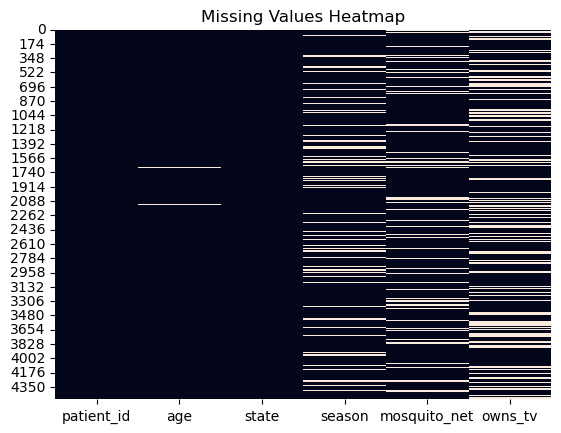

In [38]:
sns.heatmap(df1.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [39]:
# Handling missing values
# Age → median imputation
df1['age'] = pd.to_numeric(df1['age'], errors='coerce')
df1['age'] = df1['age'].fillna(df1['age'].median())

In [40]:
# Fill categorical missing values with "Unknown"
categorical_cols = ['season', 'mosquito_net', 'owns_tv']

for col in categorical_cols:
    df1[col] = df1[col].fillna('Unknown')

In [41]:
# Final check
df1.isnull().sum()

patient_id      0
age             0
state           0
season          0
mosquito_net    0
owns_tv         0
dtype: int64

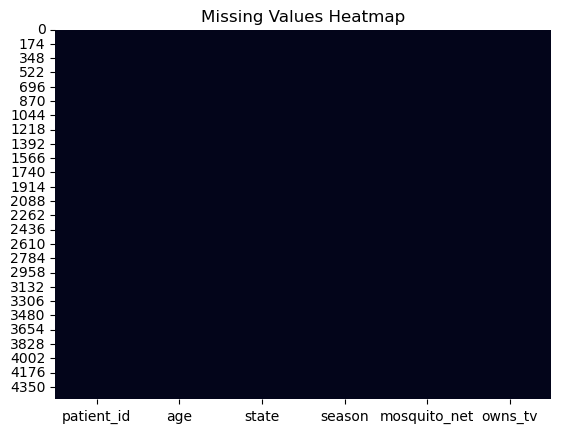

In [42]:
sns.heatmap(df1.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [43]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    4500 non-null   int64  
 1   age           4500 non-null   float64
 2   state         4500 non-null   object 
 3   season        4500 non-null   object 
 4   mosquito_net  4500 non-null   object 
 5   owns_tv       4500 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 211.1+ KB


#### EXPLORATORY DATA ANALYSIS
---
The goal of EDA is to:

* understand the dataset structure
* identify trends and patterns
* detect anomalies
* generate healthcare insights
* prepare for machine learning
---

---

#### (1). Univariate Analysis (Analyzing one variable at a time)
* What is the age distribution?
* Which states appear most frequently?
* What proportion uses mosquito nets?
* Which season dominates?

---

##### 1. Age Distribution, why important?. Age is critical in malaria vulnerability analysis

In [48]:
df1['age'].describe()

count    4500.000000
mean       40.053556
std        22.963698
min        -5.000000
25%        20.750000
50%        41.000000
75%        59.000000
max        79.000000
Name: age, dtype: float64

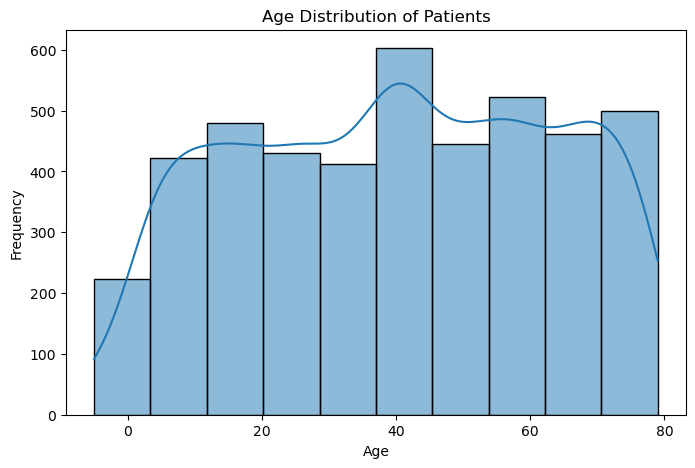

In [49]:
# Hsitogram
plt.figure(figsize=(8,5))

sns.histplot(df1['age'], bins=10, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

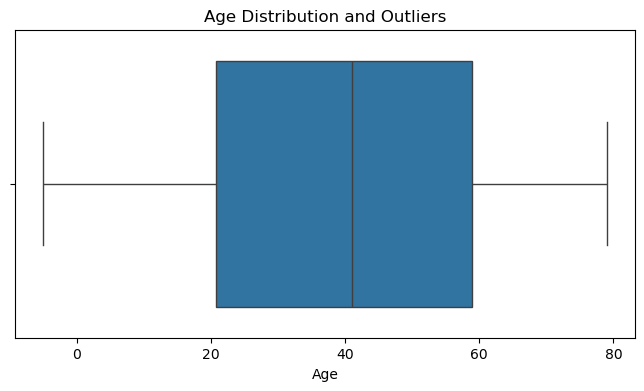

In [50]:
# Using the boxplot, we should also check for unusual ages:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df1['age']
)

plt.title('Age Distribution and Outliers')
plt.xlabel('Age')

plt.show()

---

##### Expected Questions

* Are most patients children?
* Are elderly patients represented?
* Is distribution skewed?
  
We want to determine whether the simulated patient population is:

* predominantly children
* predominantly adults
* relatively evenly distributed
* affected by extreme ages
---

##### 2. State Distribution

In [53]:
df1 ['state'].value_counts()

state
Kaduna         299
Cross River    214
Gombe          213
Rivers         211
Enugu          208
Kano           203
Lagos          202
Anambra        177
Benue          166
Imo            117
Taraba         108
Osun           108
Oyo            108
Bauchi         104
Zamfara        104
Nasarawa       103
Ondo           103
Kogi           102
Delta          102
Ekiti          101
Ogun           101
Edo            101
Niger           98
Kwara           98
Kebbi           96
Yobe            94
Katsina         93
Abuja           93
Bayelsa         92
Adamawa         90
Plateau         90
Abia            85
Sokoto          85
Jigawa          78
Ebonyi          78
Borno           75
Name: count, dtype: int64

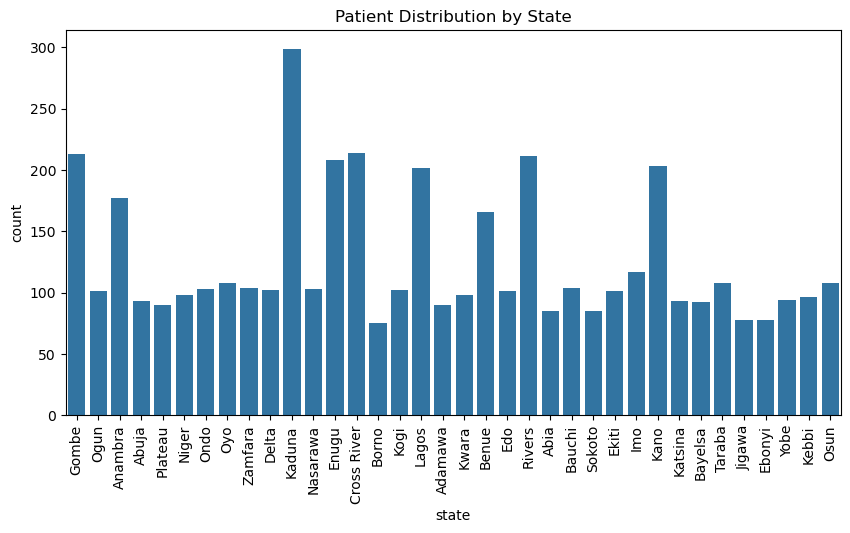

In [54]:
# Bar chart Visualization:

plt.figure(figsize=(10,5))

sns.countplot(data=df1, x='state')

plt.title("Patient Distribution by State")

plt.xticks(rotation=90)

plt.show()


In [55]:
# Get the top 10 states by patient count
df1 ['state'].value_counts().head(10)

state
Kaduna         299
Cross River    214
Gombe          213
Rivers         211
Enugu          208
Kano           203
Lagos          202
Anambra        177
Benue          166
Imo            117
Name: count, dtype: int64

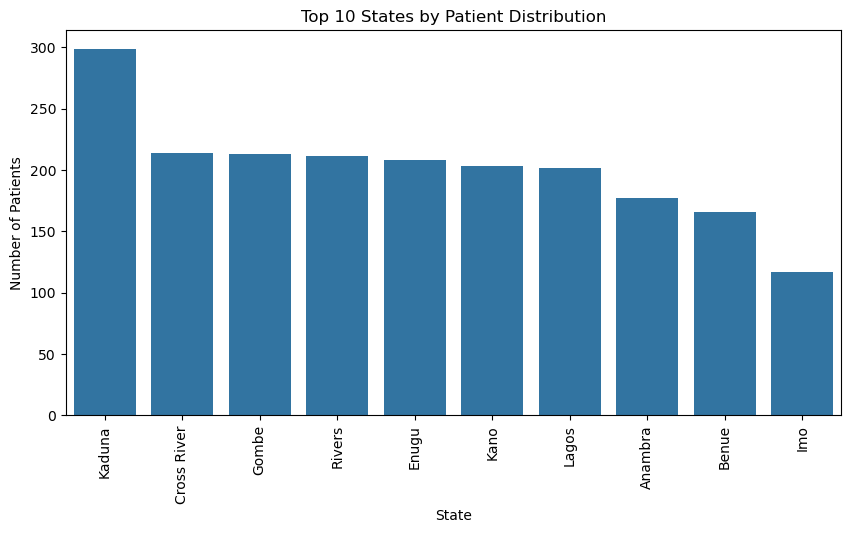

In [56]:
# Get the top 10 states by patient count
top_10_states = df1['state'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_10_states.index,
    y=top_10_states.values
)

plt.title("Top 10 States by Patient Distribution")
plt.xlabel("State")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)

plt.show()

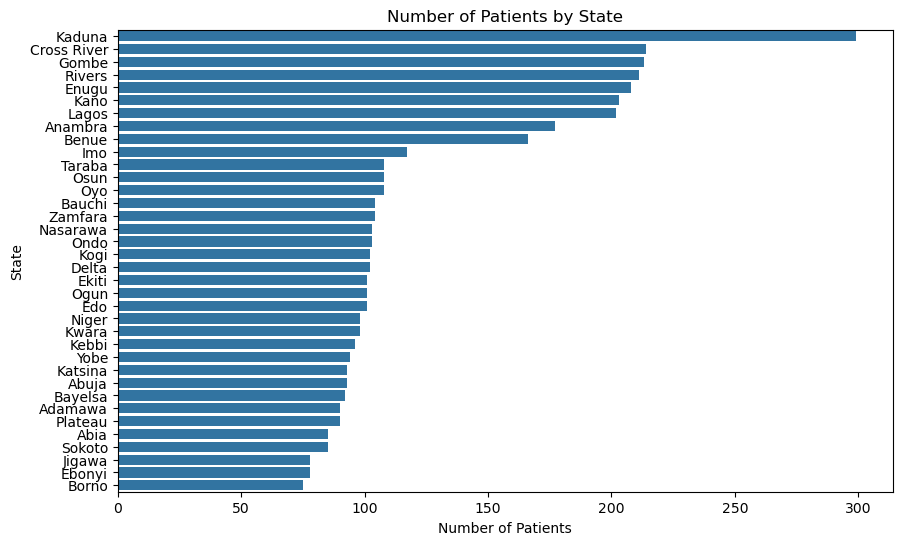

In [57]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df1,
    y='state',
    order=df1['state'].value_counts().index
)

plt.title('Number of Patients by State')
plt.xlabel('Number of Patients')
plt.ylabel('State')

plt.show()

---

##### Expected Insight

* Which states have more patient records?
* Are some regions underrepresented?

Which states contribute the most patient records?

This is important because a state with more records isn't necessarily a state with more malaria—it may simply have more patients represented in the simulation.

That's an important distinction we'll maintain throughout the project

---

##### 3. Mosquito net usage analysis

In [60]:
# Calculating the counts
df1['mosquito_net'].value_counts()

mosquito_net
No         1927
Yes        1923
Unknown     650
Name: count, dtype: int64

In [61]:
# Calculating the Proportions
df1['mosquito_net'].value_counts(normalize=True) * 100

mosquito_net
No         42.822222
Yes        42.733333
Unknown    14.444444
Name: proportion, dtype: float64

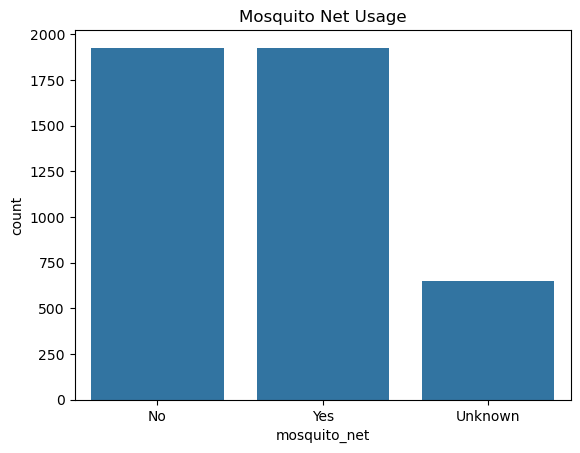

In [62]:
# Visualization:
sns.countplot(data=df1, x='mosquito_net')

plt.title("Mosquito Net Usage")

plt.show()

---

##### Expected Insight

What we're trying to understand

We want to know:

* What proportion of the simulated patients report using mosquito nets?

This becomes particularly interesting in Phase 2, when we compare net usage against other variables.

---


##### 4. Season Analysis

In [65]:
df1['season'].value_counts()

season
Rainy      2278
Dry        1450
Unknown     772
Name: count, dtype: int64

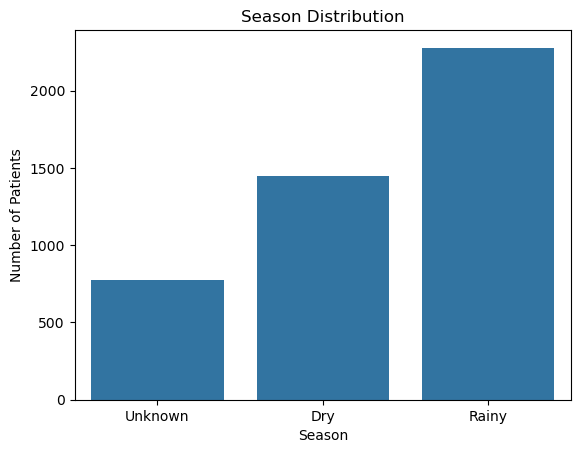

In [66]:
# Visualizations:
sns.countplot(data=df1, x='season')

plt.title("Season Distribution")
plt.xlabel('Season')
plt.ylabel('Number of Patients')
plt.show()

##### Healthcare Insight
---
Malaria often spikes during:

```text
Rainy season
```

This variable may become very predictive later.

---

##### 1. Univarate Analysis

At this point, we have answered:

| Question                             | Analysis               |
| ------------------------------------ | ---------------------- |
|1. What is the age distribution?        | Histogram + statistics |
|2. Which states appear most frequently? | State frequency        |
|3. What proportion uses mosquito nets?  | Counts + percentages   |
|4. Which season dominates?              | Season frequency       |


---

---

#### (2). Bivariate Analysis (Analyzing relationships betwenn variables)
* Does mosquito net usage vary by state?
* Does season affect malaria positivity?
* Are younger patients more vulnerable?
* Do rainy periods correlate with higher cases?

---

Like we stated earlier, here we examine relationships between **two variables**.

There is an important issue, though:

One of our original questions was:

> Does season affect malaria positivity? (Question number 2)

`malaria_patient_data` does **not** contain `malaria_result`.

So we cannot honestly answer that question using this dataset alone.

That question belongs after we integrate:

```text
malaria_patient_data
        +
malaria_test_results
```

Similarly:

> Do rainy periods correlate with higher cases?

requires:

```text
malaria_patient_data
        +
malaria_state_cases
```

We shouldn't manufacture an answer from a dataset that doesn't contain the necessary variables.

---

##### 1. Does Mosquito Net Usage Vary by State?

In [73]:
## Crosstab
net_by_state = pd.crosstab(
    df1['state'],
    df1['mosquito_net']
)

net_by_state

mosquito_net,No,Unknown,Yes
state,,,
Abia,31,12,42
Abuja,39,7,47
Adamawa,34,13,43
Anambra,78,23,76
Bauchi,45,16,43
Bayelsa,43,12,37
Benue,74,26,66
Borno,30,5,40
Cross River,103,26,85


###### Note: 
```text
Raw counts aren't enough because states may have different numbers of patients. So let's calculate percentages
```

In [75]:
net_by_state_pct = pd.crosstab(
    df1['state'],
    df1['mosquito_net'],
    normalize='index'
) * 100

net_by_state_pct

mosquito_net,No,Unknown,Yes
state,,,
Abia,36.470588,14.117647,49.411765
Abuja,41.935484,7.526882,50.537634
Adamawa,37.777778,14.444444,47.777778
Anambra,44.067797,12.994350,42.937853
Bauchi,43.269231,15.384615,41.346154
Bayelsa,46.739130,13.043478,40.217391
Benue,44.578313,15.662651,39.759036
Borno,40.000000,6.666667,53.333333
Cross River,48.130841,12.149533,39.719626


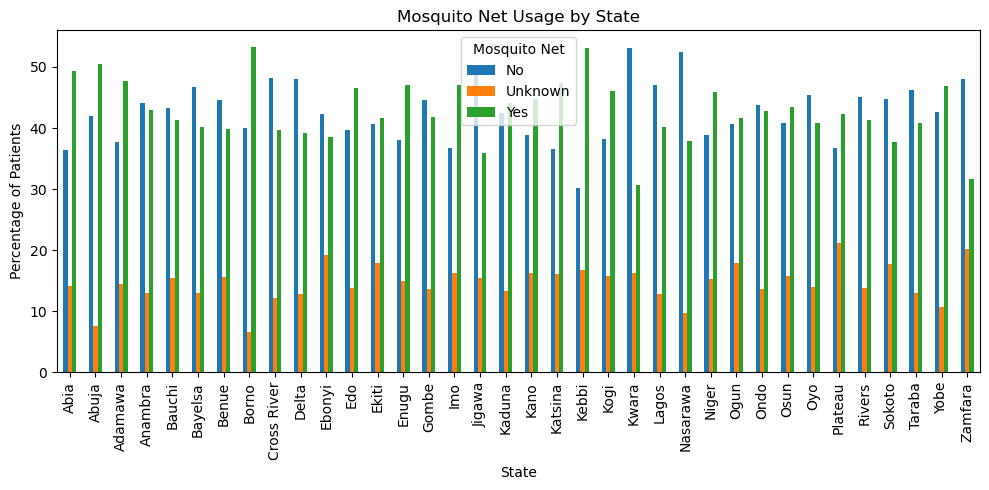

In [76]:
### Visualization
net_by_state_pct.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Mosquito Net Usage by State')
plt.xlabel('State')
plt.ylabel('Percentage of Patients')
plt.xticks(rotation=90)

plt.legend(title='Mosquito Net')

plt.tight_layout()
plt.show()

---

##### Expected Insight

Now we're asking:

> Within each state, what percentage of patients use mosquito nets?

That's much more informative than simply counting `Yes` and `No`.


---


##### 5. Does Age Vary by Mosquito Net Usage?

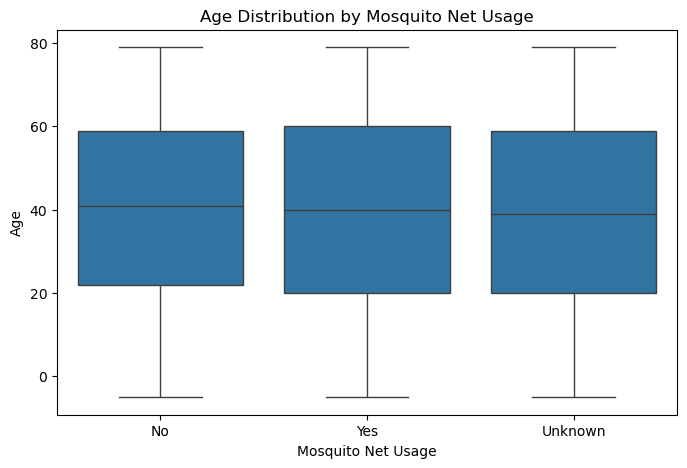

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df1,
    x='mosquito_net',
    y='age'
)

plt.title('Age Distribution by Mosquito Net Usage')
plt.xlabel('Mosquito Net Usage')
plt.ylabel('Age')

plt.show()

---

##### Expected Insight

This helps us investigate whether the simulated population using nets differs demographically from those who don't.


---


##### 6. Does Age Vary by Season?

In [82]:
df1.groupby('season')['age'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
season,,,,,
Dry,1450,40.156552,41.0,-5.0,79.0
Rainy,2278,39.834504,41.0,-5.0,79.0
Unknown,772,40.506477,40.5,-5.0,79.0


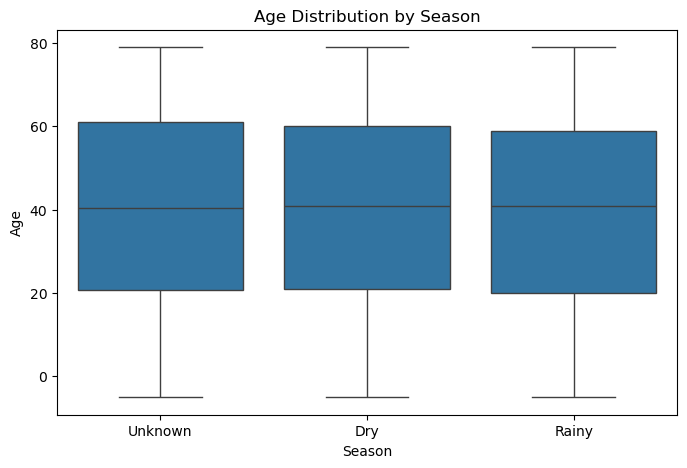

In [83]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df1,
    x='season',
    y='age'
)

plt.title('Age Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Age')

plt.show()

##### 7. Mosquito Net Usage by Season

In [85]:
season_net = pd.crosstab(
    df1['season'],
    df1['mosquito_net'],
    normalize='index'
) * 100

season_net

mosquito_net,No,Unknown,Yes
season,,,
Dry,44.344828,13.655172,42.000000
Rainy,42.581212,14.925373,42.493415
Unknown,40.673575,14.507772,44.818653


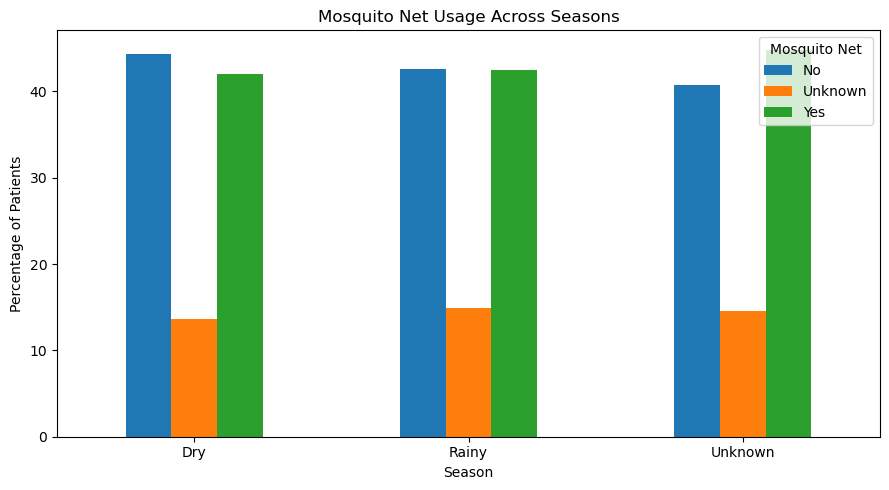

In [86]:
season_net.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Mosquito Net Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Percentage of Patients')
plt.xticks(rotation=0)

plt.legend(title='Mosquito Net')

plt.tight_layout()
plt.show()

---

##### Expected Insight

This is particularly relevant to malaria prevention and tells us whether reported preventive behavior differs between rainy and dry seasons.

---


---

---

#### (3). Multivariate Analysis (Studying multiple variable together)
* High-risk states during rainy seasons?
* Combined effect of age + mosquito net + season?
* Relationship between parasite count and reported cases?
---

##### 1. Age + Mosquito Net + Season
We can examine average age across both season and net usage

In [148]:
age_net_season = df1.groupby(
    ['season', 'mosquito_net']
)['age'].mean().reset_index()

age_net_season

,season,mosquito_net,age
0,Dry,No,40.741835
1,Dry,Unknown,39.994949
2,Dry,Yes,39.591133
3,Rainy,No,41.059794
4,Rainy,Unknown,39.970588
5,Rainy,Yes,38.558884
6,Unknown,No,39.044586
7,Unknown,Unknown,37.571429
8,Unknown,Yes,42.783237


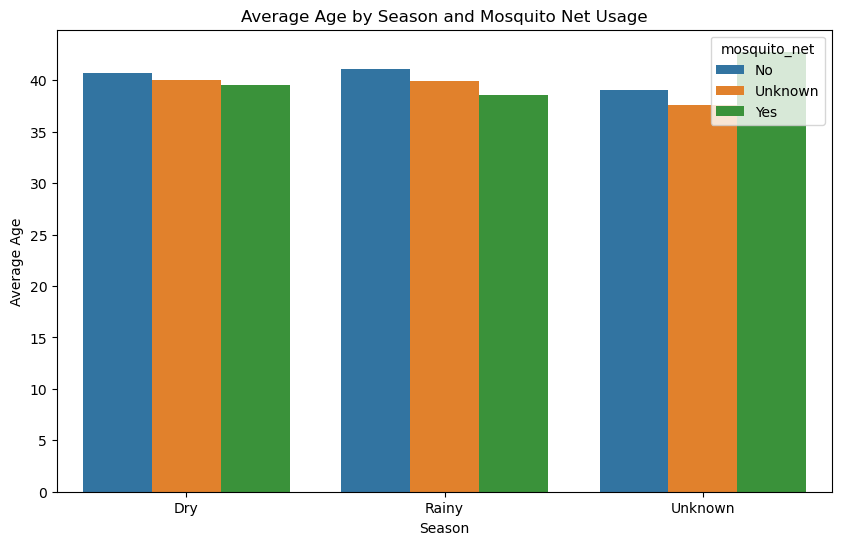

In [150]:
# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_net_season,
    x='season',
    y='age',
    hue='mosquito_net'
)

plt.title('Average Age by Season and Mosquito Net Usage')
plt.xlabel('Season')
plt.ylabel('Average Age')

plt.show()

This allows us to ask:

> Does the age profile of patients using mosquito nets differ between rainy and dry seasons?

---


##### 2. State + Season + Mosquito Net

We can examine preventive behavior across geographical and seasonal dimensions.



In [158]:
state_season_net = pd.crosstab(
    [df1['state'], df1['season']],
    df1['mosquito_net'],
    normalize='index'
) * 100

state_season_net


mosquito_net            No    Unknown        Yes
state   season                                  
Abia    Dry      46.428571  17.857143  35.714286
        Rainy    30.434783  15.217391  54.347826
        Unknown  36.363636   0.000000  63.636364
Abuja   Dry      45.833333   8.333333  45.833333
        Rainy    41.509434   5.660377  52.830189
...                    ...        ...        ...
Yobe    Rainy    50.000000   9.523810  40.476190
        Unknown   6.250000  12.500000  81.250000
Zamfara Dry      50.000000  13.157895  36.842105
        Rainy    48.076923  25.000000  26.923077
        Unknown  42.857143  21.428571  35.714286

[108 rows x 3 columns]

```

This could reveal interesting patterns such as:

```text
State A
    Rainy → high net usage
    Dry   → low net usage

State B
    Rainy → low net usage
    Dry   → high net usage
```

Because this is simulated data, we would describe these as **patterns in the simulation**, not real-world epidemiological findings.

---

##### 3. Age + State + Season

We can examine average age by state and season:



In [166]:
age_state_season = df1.groupby(
    ['state', 'season']
)['age'].mean().reset_index()

age_state_season


,state,season,age
0,Abia,Dry,42.607143
1,Abia,Rainy,39.173913
2,Abia,Unknown,41.000000
3,Abuja,Dry,44.541667
4,Abuja,Rainy,38.528302
...,...,...,...
103,Yobe,Rainy,38.595238
104,Yobe,Unknown,40.625000
105,Zamfara,Dry,34.631579
106,Zamfara,Rainy,43.557692


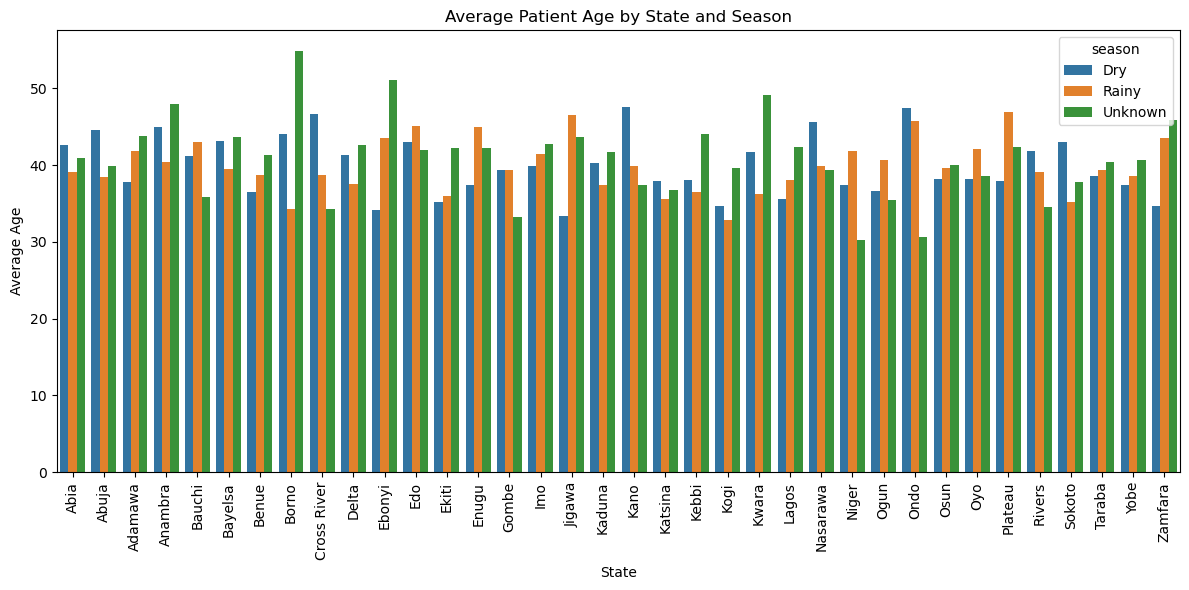

In [170]:
# Visualization
plt.figure(figsize=(12, 6))

sns.barplot(
    data=age_state_season,
    x='state',
    y='age',
    hue='season'
)

plt.title('Average Patient Age by State and Season')
plt.xlabel('State')
plt.ylabel('Average Age')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


---
#### But Here's an Important Correction

Our original multivariate questions included:

> **High-risk states during rainy seasons?**

> **Relationship between parasite count and reported cases?**

We **cannot fully answer these with `malaria_patient_data` alone.**

They require information from our other tables/columns in other datasets

---

#### What Each Dataset Can Answer

| Question                              | Patient Data | State Cases | Test Results |    Integrated   |
| ------------------------------------- | :----------: | :---------: | :----------: | :-------------: |
| Age distribution                      |       ✅      |             |              |                 |
| State distribution                    |       ✅      |             |              |                 |
| Net usage                             |       ✅      |             |              |                 |
| Season distribution                   |       ✅      |             |              |                 |
| Net usage by state                    |       ✅      |             |              |                 |
| Age vs net usage                      |       ✅      |             |              |                 |
| Age vs season                         |       ✅      |             |              |                 |
| Net usage vs season                   |       ✅      |             |              |                 |
| Season vs malaria positivity          |              |             |       ✅      |        ✅        |
| Rainy periods vs cases                |              |      ✅      |              |                 |
| High-risk states during rainy periods |              |      ✅      |              |        ✅        |
| Parasite count vs reported cases      |              |             |       ✅      | **Potentially** |
| Age + net + malaria result            |              |             |              |        ✅        |
| State + season + malaria result       |              |             |              |        ✅        |

---


##### So Our Correct Workflow Should Be

We shouldn't simply do:

```text
Patient EDA
↓
State EDA
↓
Test EDA
↓
Machine Learning
```

Instead, we should do:

```text
                    MALARIA SIMULATION DATA
                             │
          ┌──────────────────┼──────────────────┐
          │                  │                  │
          ▼                  ▼                  ▼
     PATIENT DATA       STATE CASES       TEST RESULTS
          │                  │                  │
          ▼                  ▼                  ▼
     Complete EDA        Complete EDA       Complete EDA
          │                  │                  │
          └──────────────────┼──────────────────┘
                             ▼
                    DATA INTEGRATION
                             │
                             ▼
                 CROSS-DATASET ANALYSIS
                             │
                             ▼
                  FEATURE ENGINEERING
                             │
                             ▼
                    MACHINE LEARNING
                             │
                             ▼
                       DASHBOARD
```

That's the  recommended workflow.



#### Therefore, our immediate task is:

**Finish the complete `malaria_patient_data` EDA **, including the Unvariate, Bivariate, and Multivariate analysis above, before treating the other datasets as complete.

Then we'll do the same for `malaria_state_cases`, followed by `malaria_test_results`, and only then perform the **cross-dataset EDA and integration**.

This will give us a much more rigorous project rather than jumping prematurely into modeling.


----

---

In [182]:
df2 = pd.read_csv(r"C:\Users\FRINICT\Documents\Anavami and John Class\Malaria Dataset  Analysis\Malaria Simulation Data\malaria_state_cases.csv")

In [184]:
df2

,state_name,month_reported,reported_cases,weather_notes,extra_column
0,Taraba,Sep,1355,Heavy rain,###
1,Adamawa,May,1748,flooded!!!,NaN
2,katsina,Jan,262,123,###
3,Benue,Jul,157,NaN,###
4,Kaduba,Nov,1453,Dry season,irrelevant
...,...,...,...,...,...
4495,Kwara,Feb,475,123,###
4496,Benue,Sep,218,NaN,###
4497,Yobe,Jul,781,Dry season,NaN
4498,lagos,Aug,1070,123,NaN


In [186]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   state_name      4500 non-null   object
 1   month_reported  4174 non-null   object
 2   reported_cases  4494 non-null   object
 3   weather_notes   3573 non-null   object
 4   extra_column    2980 non-null   object
dtypes: object(5)
memory usage: 175.9+ KB


In [135]:
df1.describe()

,patient_id,age
count,4500.000000,4500.000000
mean,3249.500000,40.053556
std,1299.182435,22.963698
min,1000.000000,-5.000000
25%,2124.750000,20.750000
50%,3249.500000,41.000000
75%,4374.250000,59.000000
max,5499.000000,79.000000


In [137]:
df1.describe(include='object')

,state,season,mosquito_net,owns_tv
count,4500,4500,4500,4500
unique,36,3,3,3
top,Kaduna,Rainy,No,Yes
freq,299,2278,1927,1597
